# Experimento 1 — Comparación Global de Técnicas

**Objetivo:** Comparar visualmente Prophet, LightGBM, LSTM, N-BEATS y TFT en las 6 plantas solares,  
considerando calidad de predicción (MAE, RMSE, R²), eficiencia (tiempo de entrenamiento)  
y robustez entre plantas.

**Dependencias:** Ejecutar previamente los notebooks 01-05 para generar los CSV de métricas.

In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [2]:
# ---------------------------------------------------------------------------
# CELDA 1 — Setup Colab / Local
# ---------------------------------------------------------------------------
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO = '/content/drive/MyDrive/_UOC/tfm-solar-forecasting/'
    os.chdir(REPO)
    print(f'Working dir: {os.getcwd()}')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', font_scale=1.0)
except ImportError:
    print('seaborn no disponible — usando matplotlib puro')
    sns = None

print('Setup completado.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/_UOC/tfm-solar-forecasting
Setup completado.


In [3]:
# ---------------------------------------------------------------------------
# CELDA 2 — Carga de métricas y configuración global
# ---------------------------------------------------------------------------
ROOT        = Path('.')
METRICS_DIR = ROOT / 'results' / 'ex1_compare' / 'metrics'
FIG_DIR     = ROOT / 'results' / 'figures'
OUT_DIR     = ROOT / 'results' / 'ex1_compare'
FIG_DIR.mkdir(parents=True, exist_ok=True)

CAPACIDAD_MW = {
    'UPGARNACHA': 149.0,
    'FVARENA':    150.31,
    'NBALBOA':    499.08,
    'RODRI':      175.0,
    'UFMULA':     493.74,
    'TALASOL':    300.61,
}
ZONA = {
    'UPGARNACHA': 'Norte', 'FVARENA': 'Centro', 'NBALBOA': 'Centro',
    'RODRI': 'Sur', 'UFMULA': 'Sur', 'TALASOL': 'Centro',
}
PLANTAS = ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'TALASOL', 'RODRI', 'UFMULA']
MODELOS = ['Prophet', 'LightGBM', 'LSTM', 'N-BEATS', 'TFT']
COLORS  = {
    'Prophet':  '#aec7e8',
    'LightGBM': '#ffbb78',
    'LSTM':     '#98df8a',
    'N-BEATS':  '#ff9896',
    'TFT':      '#9467bd',
}
METRIC_FILES = {
    'Prophet':  METRICS_DIR / 'prophet_metrics_summary.csv',
    'LightGBM': METRICS_DIR / 'lightgbm_metrics_summary.csv',
    'LSTM':     METRICS_DIR / 'lstm_metrics_summary.csv',
    'N-BEATS':  METRICS_DIR / 'nbeats_metrics_summary.csv',
    'TFT':      METRICS_DIR / 'tft_metrics_summary.csv',
}

frames = []
for modelo, path in METRIC_FILES.items():
    if not path.exists():
        print(f'  AVISO: {path} no encontrado')
        continue
    df = pd.read_csv(path)
    df['modelo'] = modelo
    frames.append(df)

df_all = pd.concat(frames, ignore_index=True)
df_all['zona_climatica'] = df_all['planta'].map(ZONA)
df_all = df_all[df_all['planta'].isin(PLANTAS)].copy()
df_all['capacidad_mw'] = df_all['planta'].map(CAPACIDAD_MW)
df_all['nMAE']    = df_all['MAE'] / df_all['capacidad_mw'] * 100
df_all['RMSE_MAE'] = df_all['RMSE'] / df_all['MAE']
df_all['modelo'] = pd.Categorical(df_all['modelo'], categories=MODELOS, ordered=True)
df_all['planta'] = pd.Categorical(df_all['planta'], categories=PLANTAS, ordered=True)
df_all = df_all.sort_values(['modelo', 'planta'])
modelos_disp = [m for m in MODELOS if m in df_all['modelo'].unique()]

print(f'Datos cargados: {len(df_all)} filas | {df_all["modelo"].nunique()} modelos × {df_all["planta"].nunique()} plantas')
cols_view = ['modelo', 'planta', 'MAE', 'RMSE', 'R2', 'nMAE']
if 'training_time_s' in df_all.columns:
    cols_view.append('training_time_s')
print(df_all[[c for c in cols_view if c in df_all.columns]].to_string(index=False))


Datos cargados: 30 filas | 5 modelos × 6 plantas
  modelo     planta        MAE       RMSE        R2      nMAE  training_time_s
 Prophet UPGARNACHA  42.121766  88.324267 -0.169608 28.269642        19.296682
 Prophet    FVARENA  24.612632  54.172007  0.236455 16.374580        11.587927
 Prophet    NBALBOA  99.601737 190.923660  0.514383 19.957068         8.308766
 Prophet    TALASOL  79.131563 132.608134  0.513812 26.323663        13.647459
 Prophet      RODRI  29.447457  52.900597  0.837159 16.827118        15.082558
 Prophet     UFMULA  96.837608 176.050262  0.806121 19.613077        14.095515
LightGBM UPGARNACHA  16.206378  34.739490  0.819063 10.876764         5.139334
LightGBM    FVARENA  17.556197  40.072125  0.582199 11.679993         2.664556
LightGBM    NBALBOA  75.270809 177.121308  0.582058 15.081913         7.300349
LightGBM    TALASOL  63.737654 137.221158  0.479398 21.202772         9.543844
LightGBM      RODRI  40.848150  88.503489  0.544212 23.341800         8.138979
Lig

---
## Gráfico 1 — MAE y R² por planta × modelo

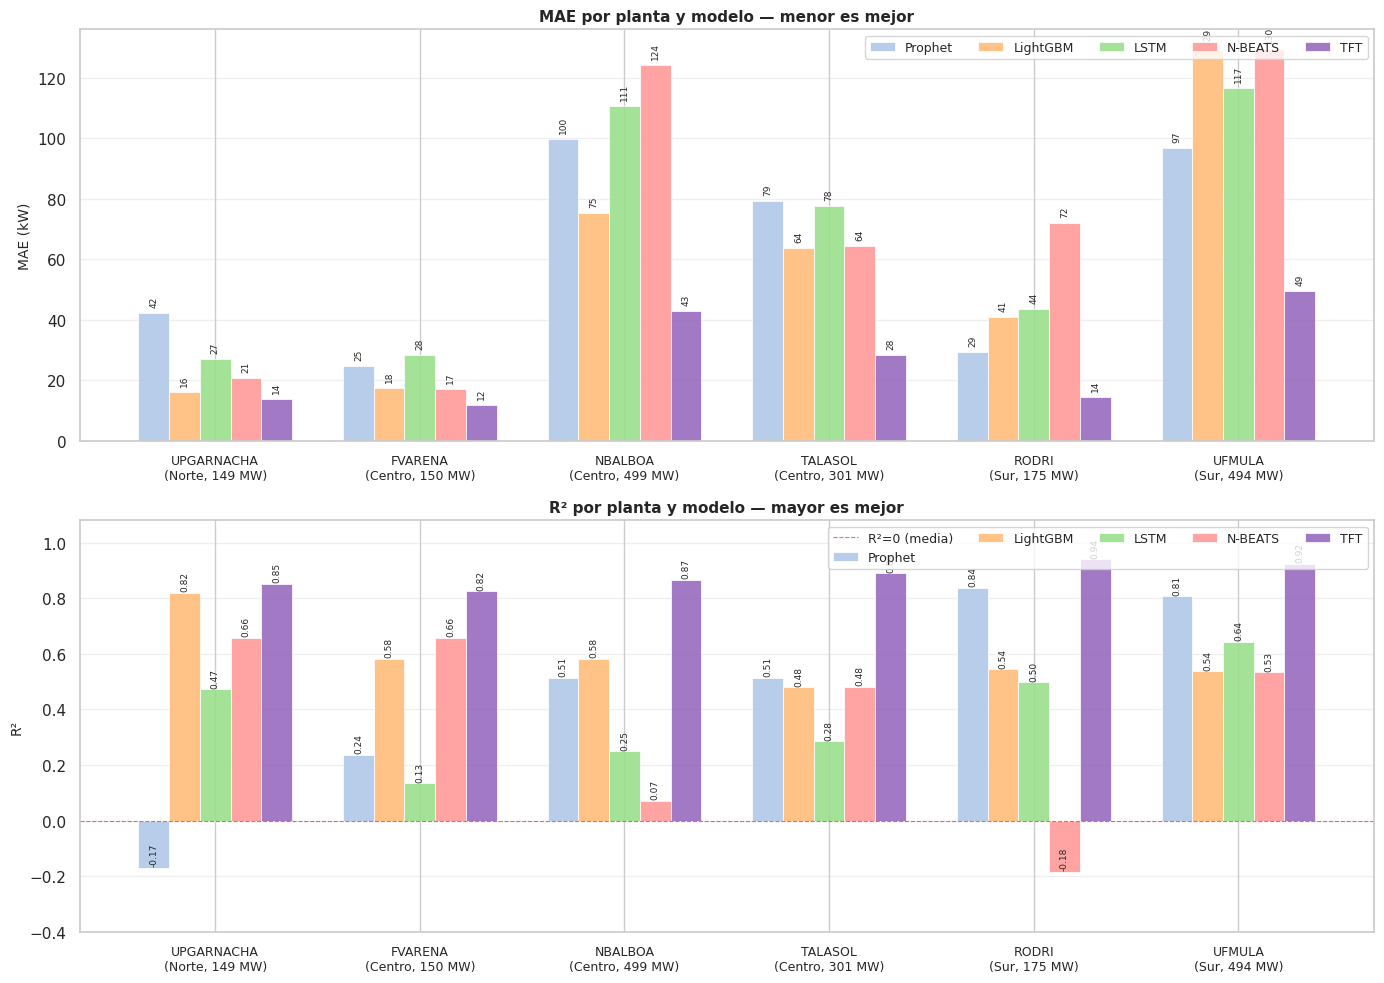

Guardado: exp1_mae_r2_bars.png


In [4]:
# ---------------------------------------------------------------------------
# CELDA 3 — Barras agrupadas MAE y R² por planta, coloreado por modelo
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

n_m   = len(modelos_disp)
width = 0.15
x     = np.arange(len(PLANTAS))

for ax_idx, (metric, ylabel, title) in enumerate([
    ('MAE', 'MAE (kW)', 'MAE por planta y modelo — menor es mejor'),
    ('R2',  'R²',       'R² por planta y modelo — mayor es mejor'),
]):
    ax = axes[ax_idx]
    for i, modelo in enumerate(modelos_disp):
        sub  = df_all[df_all['modelo'] == modelo].set_index('planta')
        vals = [sub.loc[p, metric] if p in sub.index else np.nan for p in PLANTAS]
        offset = (i - n_m / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=modelo,
                      color=COLORS[modelo], alpha=0.88, edgecolor='white', linewidth=0.6)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + (0.005 if metric == 'R2' else 2),
                        f'{v:.2f}' if metric == 'R2' else f'{v:.0f}',
                        ha='center', va='bottom', fontsize=6.5, rotation=90)

    if metric == 'R2':
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='R²=0 (media)')
        ax.set_ylim(-0.40, 1.08)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f'{p}\n({ZONA[p]}, {CAPACIDAD_MW[p]:.0f} MW)' for p in PLANTAS], fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, ncol=n_m)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'exp1_mae_r2_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: exp1_mae_r2_bars.png')


---
## Gráfico 2 — Heatmaps nMAE y R²

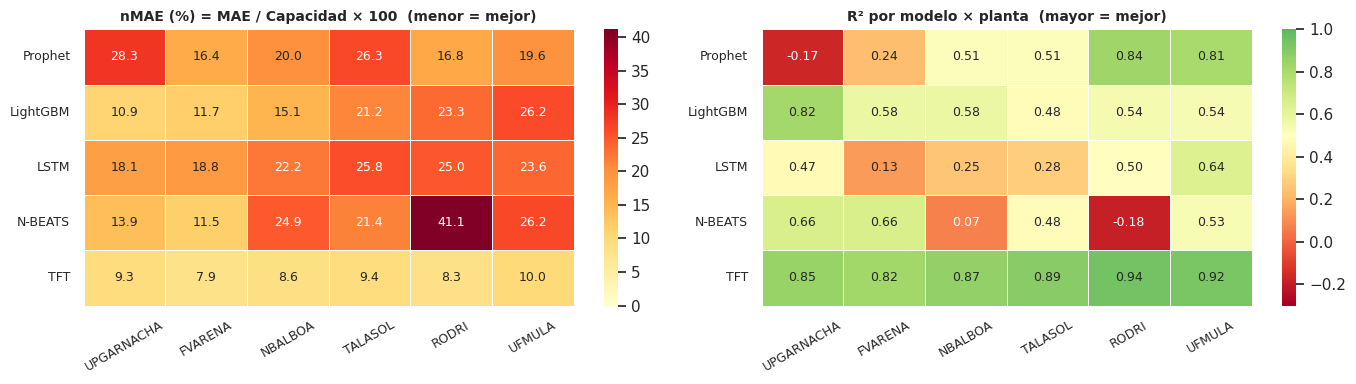

Guardado: exp1_heatmaps_quality.png


In [5]:
# ---------------------------------------------------------------------------
# CELDA 4 — Heatmaps nMAE y R² (modelo × planta)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, cmap, title in [
    (axes[0], 'nMAE', 'YlOrRd',
     'nMAE (%) = MAE / Capacidad × 100  (menor = mejor)'),
    (axes[1], 'R2',   'RdYlGn',
     'R² por modelo × planta  (mayor = mejor)'),
]:
    pivot = df_all.pivot_table(values=metric, index='modelo', columns='planta')
    pivot = pivot.reindex(index=modelos_disp, columns=PLANTAS)

    if sns:
        vmin   = 0    if metric == 'nMAE' else -0.3
        vmax   = None if metric == 'nMAE' else 1.0
        center = None if metric == 'nMAE' else 0.5
        fmt    = '.1f' if metric == 'nMAE' else '.2f'
        sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt=fmt,
                    linewidths=0.5, linecolor='white',
                    vmin=vmin, vmax=vmax, center=center,
                    annot_kws={'fontsize': 9})
    else:
        im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
        plt.colorbar(im, ax=ax)
        ax.set_xticks(range(len(PLANTAS))); ax.set_xticklabels(PLANTAS, rotation=30)
        ax.set_yticks(range(len(modelos_disp))); ax.set_yticklabels(modelos_disp)
        for i in range(len(modelos_disp)):
            for j in range(len(PLANTAS)):
                v = pivot.values[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'exp1_heatmaps_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: exp1_heatmaps_quality.png')


---
## Gráfico 3 — Distribución de errores: RMSE vs MAE

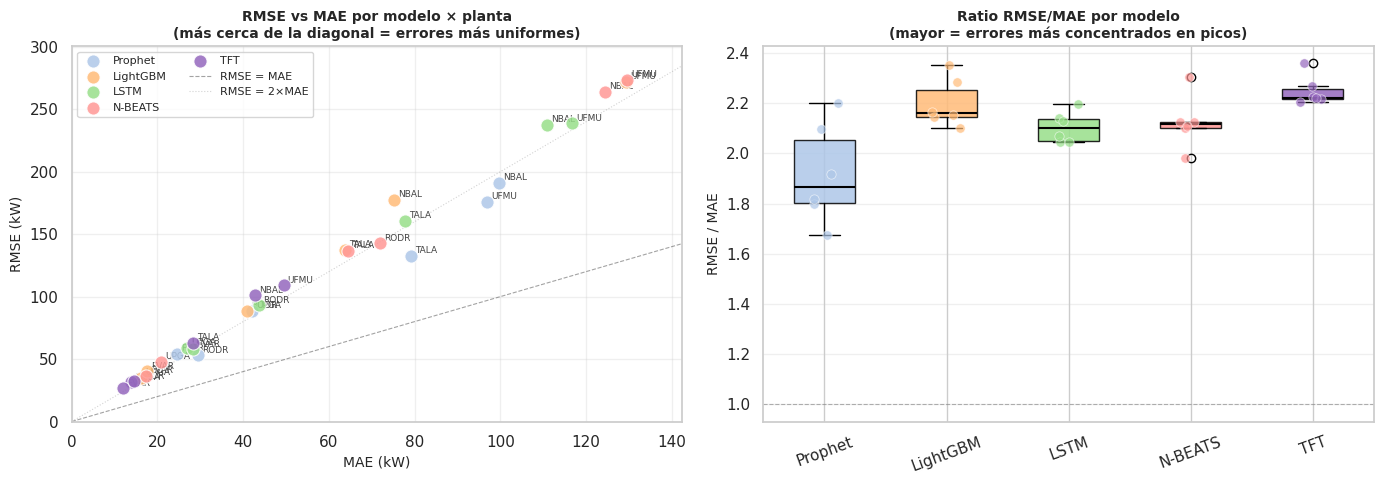

Guardado: exp1_rmse_mae_analysis.png


In [6]:
# ---------------------------------------------------------------------------
# CELDA 5 — Scatter RMSE vs MAE  +  boxplot ratio RMSE/MAE
# ---------------------------------------------------------------------------
# El ratio RMSE/MAE revela si los errores son uniformes (≈1) o concentrados en
# picos ocasionales (>>1). Para solar: horas de mediodía nublado suelen ser el culpable.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: scatter RMSE vs MAE
ax = axes[0]
for modelo in modelos_disp:
    sub = df_all[df_all['modelo'] == modelo]
    ax.scatter(sub['MAE'], sub['RMSE'],
               color=COLORS[modelo], s=90, alpha=0.85,
               edgecolors='white', linewidth=0.8, label=modelo, zorder=4)
    for _, row in sub.iterrows():
        ax.annotate(row['planta'][:4], (row['MAE'], row['RMSE']),
                    fontsize=6.5, textcoords='offset points', xytext=(3, 2), color='#444')

lim = max(df_all['RMSE'].max(), df_all['MAE'].max()) * 1.08
ax.plot([0, lim], [0, lim],     'k--', lw=0.8, alpha=0.4, label='RMSE = MAE')
ax.plot([0, lim/2], [0, lim],   ':',   lw=0.8, alpha=0.35, color='gray', label='RMSE = 2×MAE')
ax.set_xlim(0, df_all['MAE'].max()  * 1.1)
ax.set_ylim(0, df_all['RMSE'].max() * 1.1)
ax.set_xlabel('MAE (kW)', fontsize=10)
ax.set_ylabel('RMSE (kW)', fontsize=10)
ax.set_title('RMSE vs MAE por modelo × planta\n(más cerca de la diagonal = errores más uniformes)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)

# Panel derecho: boxplot ratio RMSE/MAE por modelo
ax2 = axes[1]
data_ratio = [df_all.loc[df_all['modelo'] == m, 'RMSE_MAE'].dropna().values for m in modelos_disp]
bp = ax2.boxplot(data_ratio, labels=modelos_disp, patch_artist=True,
                  medianprops={'color': 'black', 'linewidth': 1.5})
for patch, modelo in zip(bp['boxes'], modelos_disp):
    patch.set_facecolor(COLORS[modelo]); patch.set_alpha(0.85)

np.random.seed(42)
for i, (modelo, data) in enumerate(zip(modelos_disp, data_ratio), start=1):
    jitter = np.random.uniform(-0.12, 0.12, size=len(data))
    ax2.scatter(np.full(len(data), i) + jitter, data,
                color=COLORS[modelo], s=45, alpha=0.7, zorder=4,
                edgecolors='white', linewidth=0.5)

ax2.axhline(1.0, color='gray', linestyle='--', lw=0.8, alpha=0.6)
ax2.set_ylabel('RMSE / MAE', fontsize=10)
ax2.set_title('Ratio RMSE/MAE por modelo\n(mayor = errores más concentrados en picos)',
              fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', rotation=20); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'exp1_rmse_mae_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: exp1_rmse_mae_analysis.png')


---
## Gráfico 4 — Tiempos de entrenamiento

AVISO training_time_s — combinaciones faltantes (aparecerán como "n/d"):
  TFT × UPGARNACHA
  TFT × FVARENA


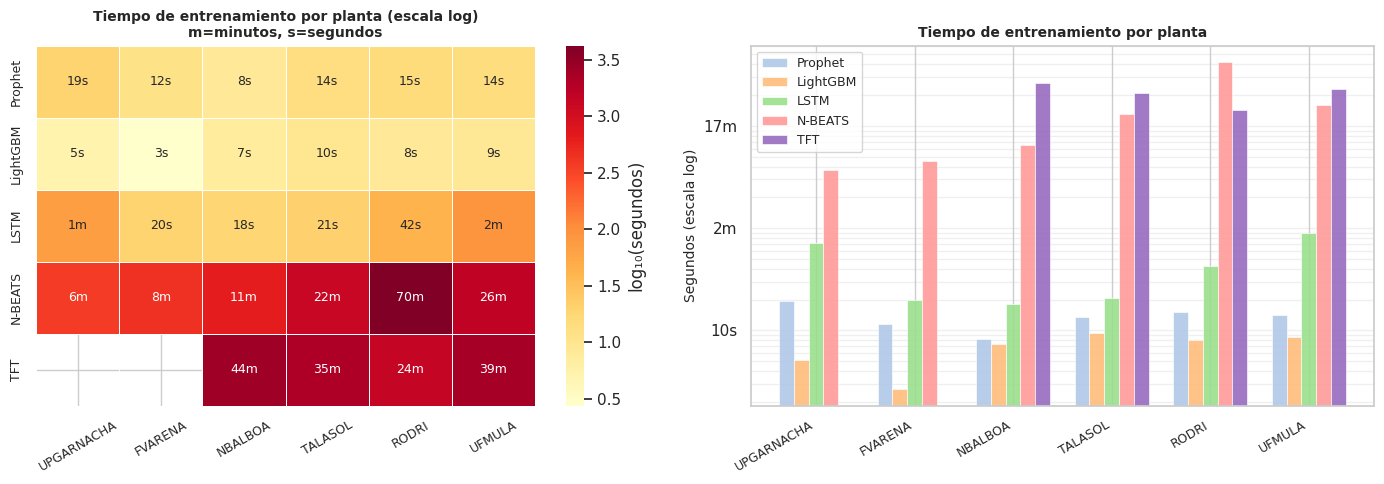

Guardado: exp1_training_time.png


In [7]:
# ---------------------------------------------------------------------------
# CELDA 6 — Heatmap y barras de tiempos de entrenamiento (escala log)
# ---------------------------------------------------------------------------
if 'training_time_s' not in df_all.columns:
    print('AVISO: training_time_s no disponible')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel izquierdo: heatmap con anotaciones en min/s
    ax = axes[0]
    pivot_t = df_all.pivot_table(values='training_time_s', index='modelo', columns='planta')
    pivot_t = pivot_t.reindex(index=modelos_disp, columns=PLANTAS)

    # Diagnóstico: advertir si hay combinaciones faltantes
    _missing = [(m, p) for m in modelos_disp for p in PLANTAS
                if pd.isna(pivot_t.loc[m, p])]
    if _missing:
        print('AVISO training_time_s — combinaciones faltantes (aparecerán como "n/d"):')
        for _m, _p in _missing:
            print(f'  {_m} × {_p}')

    # log10(t+0.1) para la escala de color; NaN → NaN (celda sin color)
    log_vals = np.log10(pivot_t.values.astype(float) + 0.1)

    if sns:
        # map() reemplaza applymap() (deprecado en pandas ≥ 2.1)
        _fmt_time = lambda v: (f'{v/60:.0f}m' if v > 60 else f'{v:.0f}s') if pd.notna(v) else 'n/d'
        annot_vals = pivot_t.map(_fmt_time)
        sns.heatmap(
            pd.DataFrame(log_vals, index=modelos_disp, columns=PLANTAS),
            ax=ax, cmap='YlOrRd', annot=annot_vals, fmt='',
            linewidths=0.5, linecolor='white',
            annot_kws={'fontsize': 9},
            cbar_kws={'label': 'log\u2081\u2080(segundos)'})
    else:
        im = ax.imshow(log_vals, cmap='YlOrRd', aspect='auto')
        plt.colorbar(im, ax=ax)
        ax.set_xticks(range(len(PLANTAS))); ax.set_xticklabels(PLANTAS, rotation=30)
        ax.set_yticks(range(len(modelos_disp))); ax.set_yticklabels(modelos_disp)
        for i in range(len(modelos_disp)):
            for j in range(len(PLANTAS)):
                v = pivot_t.values[i, j]
                txt = (f'{v/60:.0f}m' if v > 60 else f'{v:.0f}s') if not np.isnan(v) else 'n/d'
                ax.text(j, i, txt, ha='center', va='center', fontsize=8)

    ax.set_title('Tiempo de entrenamiento por planta (escala log)\nm=minutos, s=segundos',
                 fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

    # Panel derecho: barras con escala log
    ax2 = axes[1]
    x = np.arange(len(PLANTAS)); w = 0.15; n_m = len(modelos_disp)
    for i, modelo in enumerate(modelos_disp):
        sub  = df_all[df_all['modelo'] == modelo].set_index('planta')
        vals = [sub.loc[p, 'training_time_s'] if p in sub.index else np.nan for p in PLANTAS]
        offset = (i - n_m / 2 + 0.5) * w
        ax2.bar(x + offset, vals, w, label=modelo,
                color=COLORS[modelo], alpha=0.88, edgecolor='white', linewidth=0.5)
    ax2.set_yscale('log')
    ax2.set_xticks(x); ax2.set_xticklabels(PLANTAS, rotation=30, ha='right', fontsize=9)
    ax2.set_ylabel('Segundos (escala log)', fontsize=10)
    ax2.set_title('Tiempo de entrenamiento por planta', fontsize=10, fontweight='bold')
    ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3, which='both')
    ax2.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f'{v/60:.0f}m' if v >= 60 else f'{v:.0f}s'))

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'exp1_training_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: exp1_training_time.png')


---
## Gráfico 5 — Frontera de eficiencia: calidad vs coste computacional

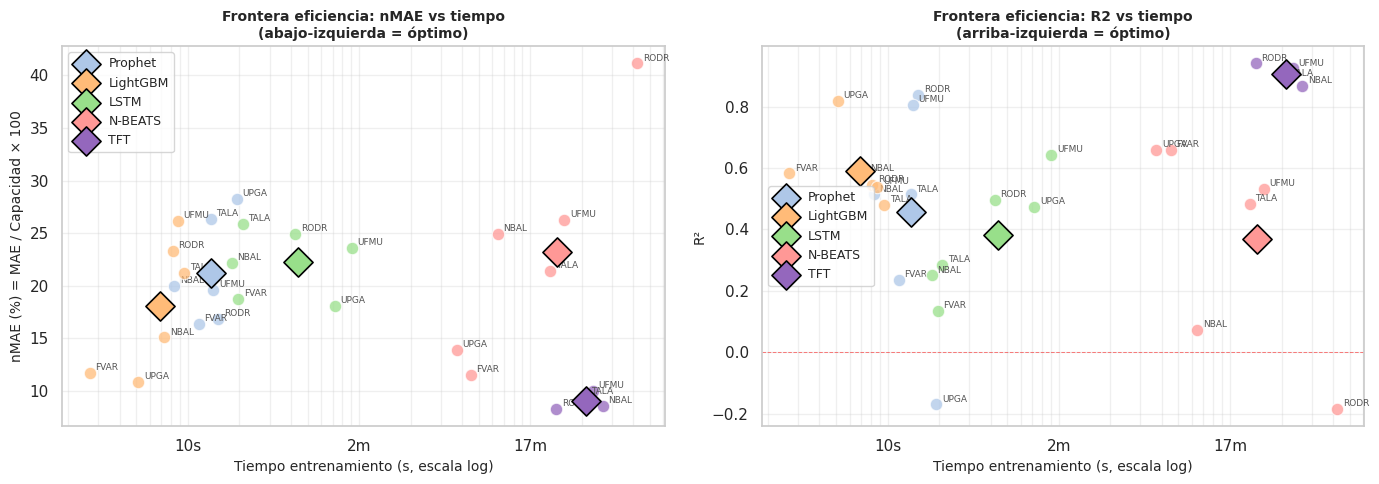

Guardado: exp1_efficiency_frontier.png


In [8]:
# ---------------------------------------------------------------------------
# CELDA 7 — Scatter nMAE / R² vs tiempo de entrenamiento
# ---------------------------------------------------------------------------
if 'training_time_s' in df_all.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric, ylabel, best_dir in [
        (axes[0], 'nMAE', 'nMAE (%) = MAE / Capacidad × 100', 'abajo-izquierda'),
        (axes[1], 'R2',   'R²',                                'arriba-izquierda'),
    ]:
        for modelo in modelos_disp:
            sub = df_all[df_all['modelo'] == modelo].dropna(subset=['training_time_s', metric])
            ax.scatter(sub['training_time_s'], sub[metric],
                       color=COLORS[modelo], s=80, alpha=0.75,
                       edgecolors='white', linewidth=0.8, zorder=3)
            for _, row in sub.iterrows():
                ax.annotate(row['planta'][:4], (row['training_time_s'], row[metric]),
                            fontsize=6.5, textcoords='offset points', xytext=(4, 2), color='#555')
            # Media del modelo (diamante grande)
            ax.scatter(sub['training_time_s'].mean(), sub[metric].mean(),
                       color=COLORS[modelo], s=220, marker='D', label=modelo,
                       edgecolors='black', linewidth=1.2, zorder=5)

        ax.set_xscale('log')
        ax.set_xlabel('Tiempo entrenamiento (s, escala log)', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(f'Frontera eficiencia: {metric} vs tiempo\n({best_dir} = óptimo)',
                     fontsize=10, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _: f'{v/60:.0f}m' if v >= 60 else f'{v:.0f}s'))
        if metric == 'R2':
            ax.axhline(0, color='red', linestyle='--', lw=0.7, alpha=0.5)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'exp1_efficiency_frontier.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: exp1_efficiency_frontier.png')


---
## Gráfico 6 — Radar: perfil multidimensional de cada modelo

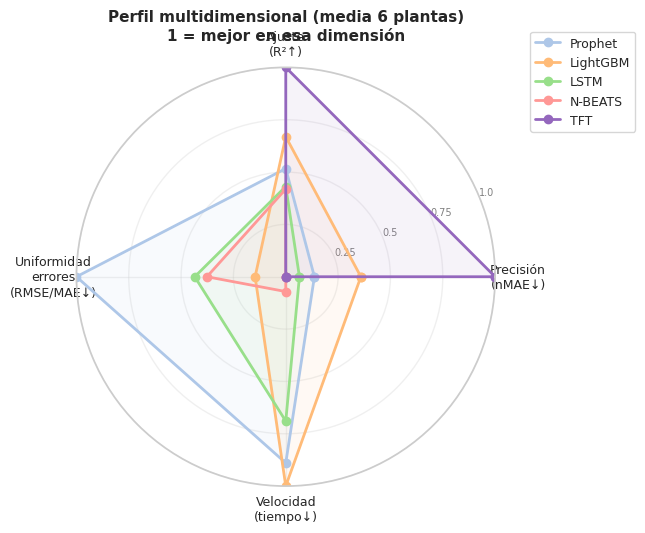

Guardado: exp1_radar_models.png

Valores normalizados (1=mejor):
          Precisión\n(nMAE↓)  Ajuste\n(R²↑)  Uniformidad\nerrores\n(RMSE/MAE↓)  Velocidad\n(tiempo↓)
modelo                                                                                              
Prophet                0.137          0.517                              1.000                 0.890
LightGBM               0.359          0.669                              0.146                 1.000
LSTM                   0.065          0.431                              0.435                 0.690
N-BEATS                0.000          0.419                              0.377                 0.071
TFT                    1.000          1.000                              0.000                 0.000


In [9]:
# ---------------------------------------------------------------------------
# CELDA 8 — Radar chart: perfil normalizado por modelo (medias 6 plantas)
# ---------------------------------------------------------------------------
# Dimensiones (todas en [0,1], 1 = mejor):
#   Precisión   = 1 - nMAE_norm
#   Ajuste      = R2_norm (clip a 0)
#   Uniformidad = 1 - RMSE/MAE_norm
#   Velocidad   = 1 - log10(t)_norm   (solo si disponible)
cols_agg = ['nMAE', 'R2', 'RMSE_MAE']
if 'training_time_s' in df_all.columns:
    cols_agg.append('training_time_s')

df_mean = df_all.groupby('modelo', observed=True)[cols_agg].mean()
df_norm = pd.DataFrame(index=df_mean.index)

def norm_inv(s):  # invertir y normalizar a [0,1]
    rng = s.max() - s.min()
    return 1 - (s - s.min()) / (rng + 1e-9)

def norm_dir(s):  # directo (mayor = mejor)
    rng = s.max() - s.min()
    return (s.clip(lower=0) - 0) / (s.max() + 1e-9)

df_norm['Precisión\n(nMAE↓)']            = norm_inv(df_mean['nMAE'])
df_norm['Ajuste\n(R²↑)']                 = norm_dir(df_mean['R2'])
df_norm['Uniformidad\nerrores\n(RMSE/MAE↓)'] = norm_inv(df_mean['RMSE_MAE'])
if 'training_time_s' in df_mean.columns:
    log_t = np.log10(df_mean['training_time_s'] + 1)
    df_norm['Velocidad\n(tiempo↓)'] = norm_inv(log_t)

categories = list(df_norm.columns)
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
for modelo in df_norm.index:
    vals = df_norm.loc[modelo].tolist() + [df_norm.loc[modelo].tolist()[0]]
    ax.plot(angles, vals, 'o-', lw=2, label=modelo, color=COLORS.get(modelo, 'gray'))
    ax.fill(angles, vals, alpha=0.08, color=COLORS.get(modelo, 'gray'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=7, color='gray')
ax.set_ylim(0, 1)
ax.set_title('Perfil multidimensional (media 6 plantas)\n1 = mejor en esa dimensión',
             fontsize=11, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'exp1_radar_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: exp1_radar_models.png')
print()
print('Valores normalizados (1=mejor):')
print(df_norm.round(3).to_string())


---
## Gráfico 7 — Comparación por zona climática

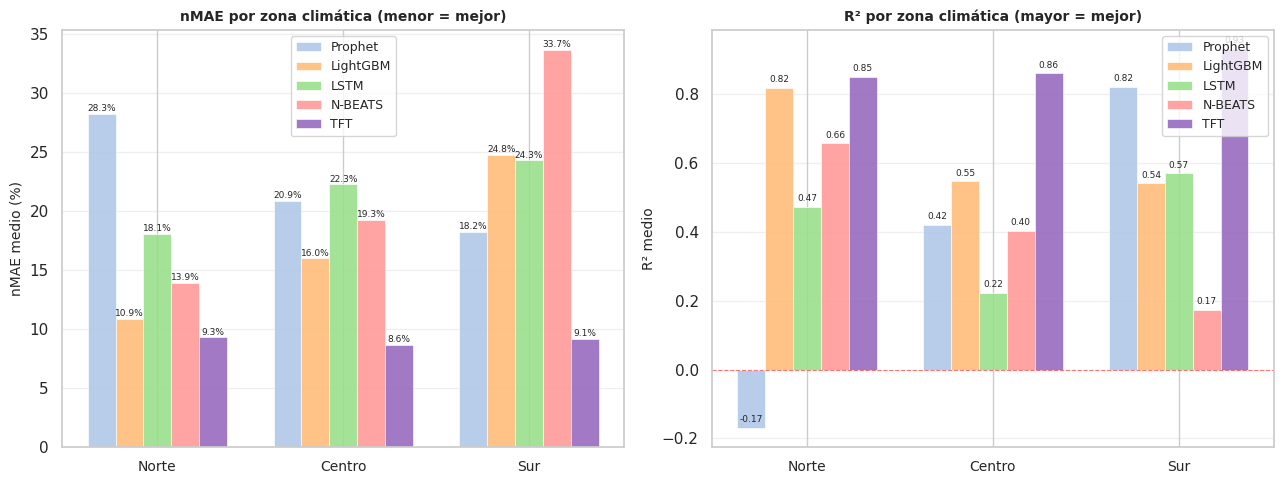

Guardado: exp1_zona_climatica.png


In [10]:
# ---------------------------------------------------------------------------
# CELDA 9 — nMAE y R² medio por zona climática × modelo
# ---------------------------------------------------------------------------
# ¿Los modelos se comportan igual en Norte / Centro / Sur?
zonas = ['Norte', 'Centro', 'Sur']
df_z_mae = df_all.groupby(['modelo', 'zona_climatica'], observed=True)['nMAE'].mean().reset_index()
df_z_r2  = df_all.groupby(['modelo', 'zona_climatica'], observed=True)['R2'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(zonas)); n_m = len(modelos_disp); w = 0.15

for ax, df_z, col, ylabel, title in [
    (axes[0], df_z_mae, 'nMAE', 'nMAE medio (%)', 'nMAE por zona climática (menor = mejor)'),
    (axes[1], df_z_r2,  'R2',   'R² medio',        'R² por zona climática (mayor = mejor)'),
]:
    for i, modelo in enumerate(modelos_disp):
        sub  = df_z[df_z['modelo'] == modelo].set_index('zona_climatica')
        vals = [sub.loc[z, col] if z in sub.index else np.nan for z in zonas]
        offset = (i - n_m / 2 + 0.5) * w
        bars = ax.bar(x + offset, vals, w, label=modelo,
                      color=COLORS[modelo], alpha=0.88, edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + (0.01 if col == 'R2' else 0.05),
                        f'{v:.2f}' if col == 'R2' else f'{v:.1f}%',
                        ha='center', va='bottom', fontsize=6.5)
    if col == 'R2':
        ax.axhline(0, color='red', linestyle='--', lw=0.8, alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels(zonas, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'exp1_zona_climatica.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: exp1_zona_climatica.png')


---
## Gráfico 7b — Error segmentado por condición meteorológica


nMAE (%) por condición meteorológica (horas diurnas):
modelo               Prophet  LightGBM   LSTM  N-BEATS    TFT
Condición                                                    
Despejado\n(<20%)      36.62     47.41  52.36    55.16  15.74
Parcial\n(20-60%)      39.48     37.97  45.35    45.30  17.84
Nublado\n(60-80%)      38.65     35.08  48.64    44.44  18.90
Muy nublado\n(>80%)    32.80     20.48  33.57    29.98  13.71


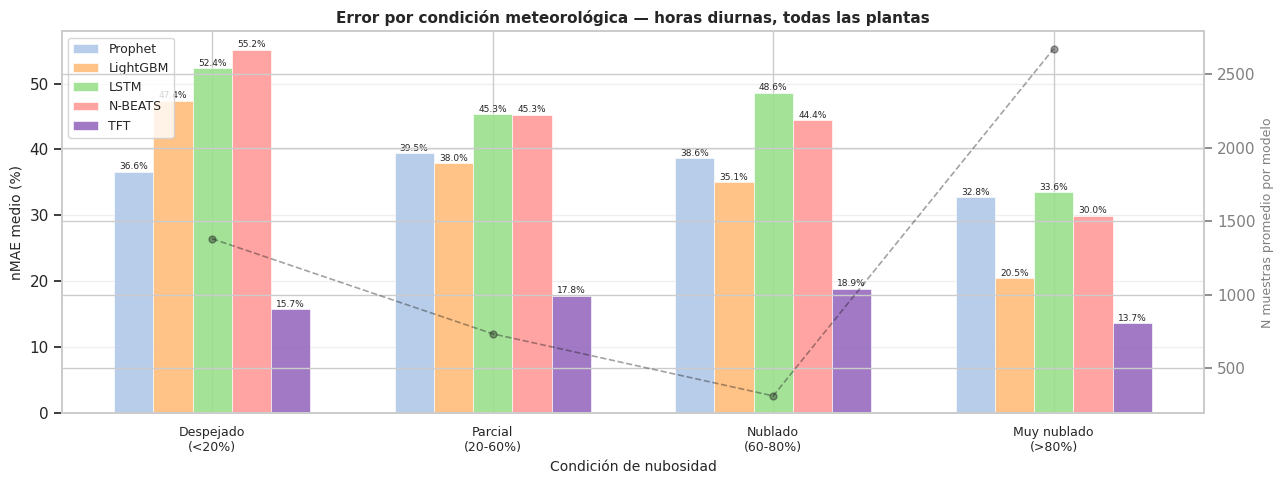

Guardado: exp1_error_por_condicion_meteo.png


In [11]:
# ---------------------------------------------------------------------------
# CELDA 9b — Error (nMAE) segmentado por cloud_cover
# ---------------------------------------------------------------------------
# Carga predicciones de test de todos los modelos, las une con los metadatos
# meteorológicos (cloud_cover) y segmenta el nMAE por condición de nubosidad.
# Solo horas diurnas (hora 7-20 UTC).

PRED_DIR = METRICS_DIR

# --- 1. Metadatos de referencia (Prophet tiene cloud_cover) -------------------
_df_ref = pd.read_csv(PRED_DIR / 'prophet_predictions.csv')
_df_ref['ts_key'] = pd.to_datetime(_df_ref['timestamp']).dt.strftime('%Y-%m-%d %H')
_meta = _df_ref[['ts_key', 'planta_nombre', 'cloud_cover', 'hora']].copy()

# --- 2. Cargar predicciones de todos los modelos y unir con metadatos --------
_pred_files = {
    'Prophet':  'prophet_predictions.csv',
    'LightGBM': 'lightgbm_predictions.csv',
    'LSTM':     'lstm_predictions.csv',
    'N-BEATS':  'nbeats_predictions.csv',
    'TFT':      'tft_predictions.csv',
}

_frames_cloud = []
for modelo, fname in _pred_files.items():
    _path = PRED_DIR / fname
    if not _path.exists() or modelo not in modelos_disp:
        continue
    _df_m = pd.read_csv(_path)
    _df_m['ts_key'] = pd.to_datetime(_df_m['timestamp']).dt.strftime('%Y-%m-%d %H')
    _df_m = _df_m.merge(
        _meta[['ts_key', 'planta_nombre', 'cloud_cover', 'hora']],
        on=['ts_key', 'planta_nombre'], how='left',
        suffixes=('', '_ref')
    )
    # Usar cloud_cover_ref cuando el modelo no tiene la suya
    if 'cloud_cover' not in _df_m.columns or _df_m['cloud_cover'].isna().all():
        _df_m['cloud_cover'] = _df_m['cloud_cover_ref']
    elif _df_m['cloud_cover'].isna().any():
        _mask = _df_m['cloud_cover'].isna()
        _df_m.loc[_mask, 'cloud_cover'] = _df_m.loc[_mask, 'cloud_cover_ref']
    if 'hora' not in _df_m.columns or _df_m['hora'].isna().all():
        _df_m['hora'] = _df_m['hora_ref']
    _df_m['modelo']       = modelo
    _df_m['capacidad_mw'] = _df_m['planta_nombre'].map(CAPACIDAD_MW)
    _df_m['abs_error']    = (_df_m['y_true'] - _df_m['y_pred']).abs()
    _frames_cloud.append(_df_m)

_df_cloud = pd.concat(_frames_cloud, ignore_index=True)

# --- 3. Filtrar horas diurnas y valores válidos -------------------------------
_df_day = _df_cloud[
    _df_cloud['hora'].between(7, 20) &
    _df_cloud['cloud_cover'].notna() &
    _df_cloud['capacidad_mw'].notna()
].copy()

# --- 4. Segmentar por cuartiles de nubosidad ---------------------------------
_bins   = [0, 20, 60, 80, 100]
_labels = ['Despejado\n(<20%)', 'Parcial\n(20-60%)', 'Nublado\n(60-80%)', 'Muy nublado\n(>80%)']
_df_day['condicion'] = pd.cut(
    _df_day['cloud_cover'], bins=_bins, labels=_labels, include_lowest=True
)
_df_day['nMAE'] = _df_day['abs_error'] / _df_day['capacidad_mw'] * 100

# Agregar: nMAE medio por condición × modelo
_df_seg = (
    _df_day.groupby(['modelo', 'condicion'], observed=True)['nMAE']
    .mean()
    .reset_index()
)

# Tabla pivotada
_df_pivot = _df_seg.pivot(index='condicion', columns='modelo', values='nMAE')
_df_pivot = _df_pivot.reindex(columns=modelos_disp)
_df_pivot.index.name = 'Condición'
print("nMAE (%) por condición meteorológica (horas diurnas):")
print(_df_pivot.round(2).to_string())

# --- 5. Gráfico de barras agrupadas ------------------------------------------
_n_cond   = len(_labels)
_n_mod    = len(modelos_disp)
_w        = 0.14
_x        = np.arange(_n_cond)

fig, ax = plt.subplots(figsize=(13, 5))

for i, modelo in enumerate(modelos_disp):
    sub  = _df_seg[_df_seg['modelo'] == modelo].set_index('condicion')
    vals = [float(sub.loc[lbl, 'nMAE']) if lbl in sub.index else np.nan
            for lbl in _labels]
    offset = (i - _n_mod / 2 + 0.5) * _w
    bars = ax.bar(_x + offset, vals, _w,
                  label=modelo, color=COLORS[modelo],
                  alpha=0.88, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.05,
                    f'{v:.1f}%',
                    ha='center', va='bottom', fontsize=6.5)

# Eje secundario: número de muestras por condición (todas las plantas)
_counts = _df_day.groupby('condicion', observed=True)['abs_error'].count() / _n_mod
ax2 = ax.twinx()
ax2.plot(_x, [_counts.get(lbl, 0) for lbl in _labels],
         'k--', marker='o', ms=5, lw=1.2, alpha=0.4, label='N muestras')
ax2.set_ylabel('N muestras promedio por modelo', fontsize=9, color='grey')
ax2.tick_params(axis='y', colors='grey')

ax.set_xticks(_x)
ax.set_xticklabels(_labels, fontsize=9)
ax.set_xlabel('Condición de nubosidad', fontsize=10)
ax.set_ylabel('nMAE medio (%)', fontsize=10)
ax.set_title(
    'Error por condición meteorológica — horas diurnas, todas las plantas',
    fontsize=11, fontweight='bold'
)
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'exp1_error_por_condicion_meteo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: exp1_error_por_condicion_meteo.png')


---
## Gráfico 8 — Dashboard por planta (2×3)

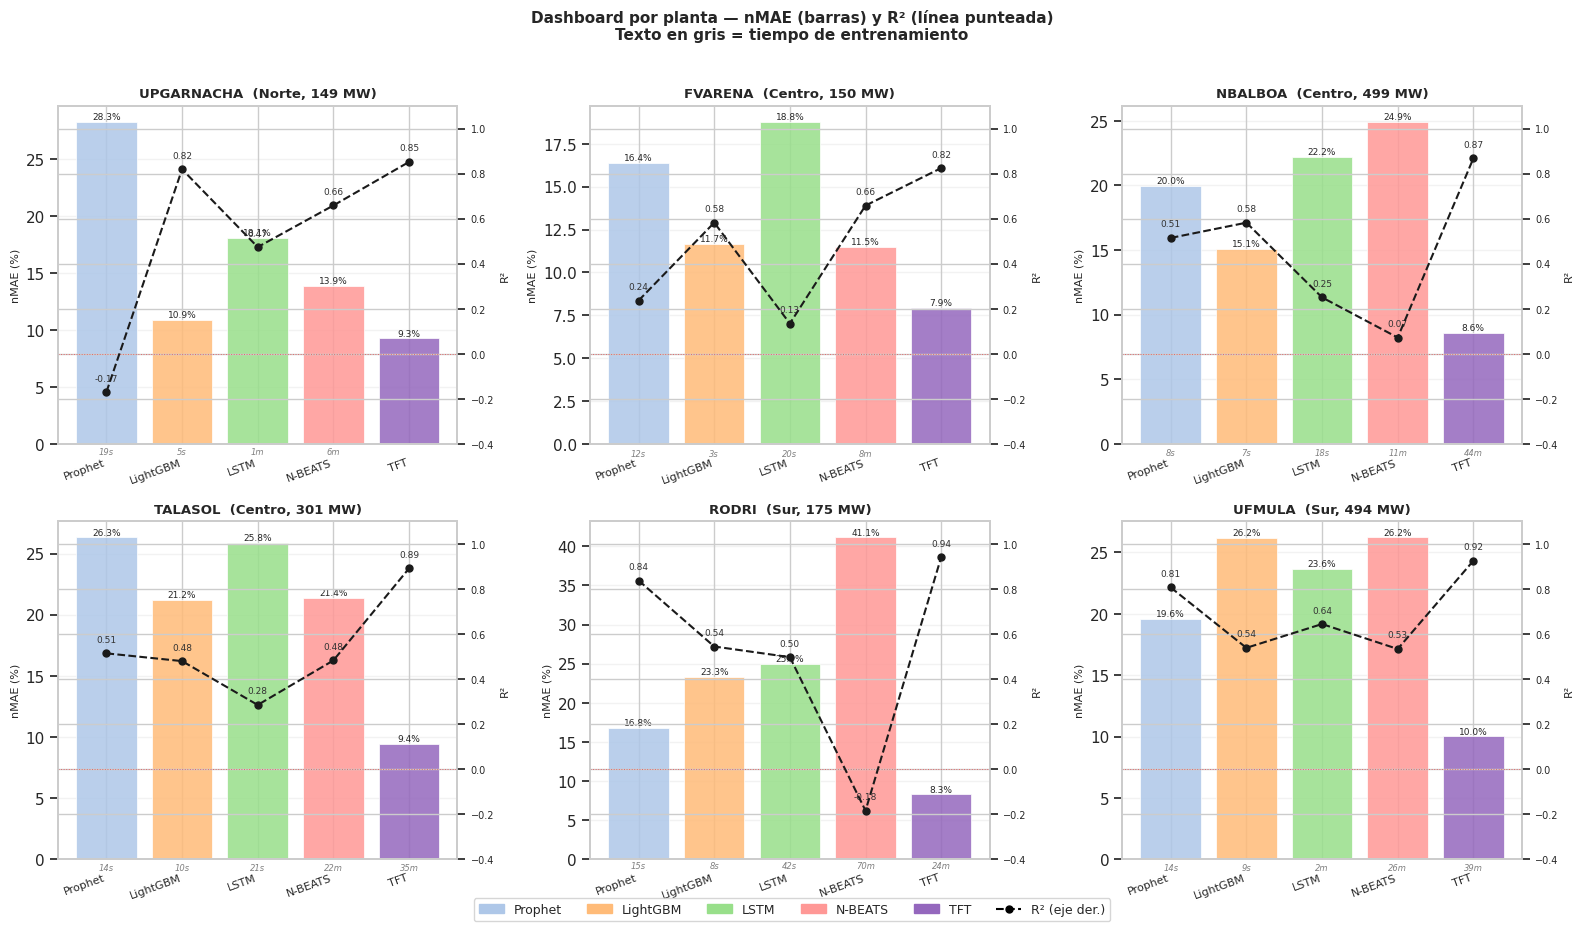

Guardado: exp1_dashboard_plantas.png


In [12]:
# ---------------------------------------------------------------------------
# CELDA 10 — Dashboard 2×3: nMAE (barras) + R² (línea) + tiempo (texto)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax_idx, planta in enumerate(PLANTAS):
    ax = axes[ax_idx]
    sub = df_all[df_all['planta'] == planta].set_index('modelo')
    mae_vals  = [sub.loc[m, 'nMAE'] if m in sub.index else np.nan for m in modelos_disp]
    r2_vals   = [sub.loc[m, 'R2']   if m in sub.index else np.nan for m in modelos_disp]
    t_vals    = ([sub.loc[m, 'training_time_s'] if m in sub.index else np.nan
                  for m in modelos_disp]
                 if 'training_time_s' in sub.columns else [np.nan] * len(modelos_disp))

    x_pos = np.arange(len(modelos_disp))
    ax.bar(x_pos, mae_vals,
           color=[COLORS[m] for m in modelos_disp],
           alpha=0.85, edgecolor='white', linewidth=0.6)

    ax2t = ax.twinx()
    ax2t.plot(x_pos, r2_vals, 'k--o', markersize=5, lw=1.5, zorder=5)
    ax2t.axhline(0, color='red', linestyle=':', lw=0.7, alpha=0.5)
    ax2t.set_ylim(-0.4, 1.1)
    ax2t.set_ylabel('R²', fontsize=8)
    ax2t.tick_params(axis='y', labelsize=7)
    for xi, rv in zip(x_pos, r2_vals):
        if not np.isnan(rv):
            ax2t.text(xi, rv + 0.05, f'{rv:.2f}', ha='center', fontsize=6.5, color='#333')

    for xi, (mv, tv) in enumerate(zip(mae_vals, t_vals)):
        if not np.isnan(mv):
            ax.text(xi, mv + 0.05, f'{mv:.1f}%', ha='center', va='bottom', fontsize=6.5)
        if not np.isnan(tv):
            ax.text(xi, -0.3, f'{tv/60:.0f}m' if tv > 60 else f'{tv:.0f}s',
                    ha='center', va='top', fontsize=6, color='gray', style='italic')

    ax.set_title(f'{planta}  ({ZONA[planta]}, {CAPACIDAD_MW[planta]:.0f} MW)',
                 fontsize=9.5, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(modelos_disp, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('nMAE (%)', fontsize=8)
    ax.grid(axis='y', alpha=0.25)

patches = [mpatches.Patch(color=COLORS[m], label=m) for m in modelos_disp]
patches.append(Line2D([0], [0], color='black', linestyle='--', marker='o',
                       markersize=5, label='R² (eje der.)'))
fig.legend(handles=patches, loc='lower center', ncol=len(modelos_disp) + 1,
           fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Dashboard por planta — nMAE (barras) y R² (línea punteada)\n'
             'Texto en gris = tiempo de entrenamiento',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'exp1_dashboard_plantas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: exp1_dashboard_plantas.png')


---
## Tabla resumen y ranking

In [13]:
# ---------------------------------------------------------------------------
# CELDA 11 — Ranking compuesto
# ---------------------------------------------------------------------------
agg_cols = ['MAE', 'RMSE', 'R2', 'nMAE', 'RMSE_MAE']
if 'training_time_s' in df_all.columns:
    agg_cols.append('training_time_s')
df_rank = df_all.groupby('modelo', observed=True)[agg_cols].mean().round(4)
df_rank = df_rank.reindex(modelos_disp)
df_rank['n_plantas']   = df_all.groupby('modelo', observed=True)['planta'].nunique()
df_rank['rank_nMAE']   = df_rank['nMAE'].rank(ascending=True)
df_rank['rank_R2']     = df_rank['R2'].rank(ascending=False)
df_rank['rank_RMSE_MAE'] = df_rank['RMSE_MAE'].rank(ascending=True)
df_rank['rank_calidad']  = (df_rank['rank_nMAE'] + df_rank['rank_R2'] + df_rank['rank_RMSE_MAE']).round(1)
if 'training_time_s' in df_rank.columns:
    df_rank['rank_vel'] = df_rank['training_time_s'].rank(ascending=True)
    df_rank['rank_global'] = (
        df_rank['rank_nMAE']   * 0.35 +
        df_rank['rank_R2']     * 0.35 +
        df_rank['rank_RMSE_MAE'] * 0.15 +
        df_rank['rank_vel']    * 0.15
    ).round(2)

print('=' * 70)
print('  RANKING EXPERIMENTO 1  (media 6 plantas activas)')
print('=' * 70)
cols_show = ['n_plantas', 'nMAE', 'R2', 'RMSE_MAE', 'rank_calidad']
if 'training_time_s' in df_rank.columns:
    cols_show += ['training_time_s', 'rank_global']
print(df_rank[[c for c in cols_show if c in df_rank.columns]]
      .sort_values('rank_calidad').to_string())
print()
print('Notas:')
print('  nMAE      = MAE / cap_instalada × 100 (%)')
print('  RMSE/MAE  = ratio concentración errores (1=uniforme, >2=picos)')
print('  rank_calidad = avg rangos nMAE↓ + R²↑ + RMSE/MAE↓  (menor = mejor)')
if 'training_time_s' in df_rank.columns:
    print('  rank_global  = 35%·nMAE + 35%·R² + 15%·RMSE/MAE + 15%·velocidad')


  RANKING EXPERIMENTO 1  (media 6 plantas activas)
          n_plantas     nMAE      R2  RMSE_MAE  rank_calidad  training_time_s  rank_global
modelo                                                                                    
Prophet           6  21.2275  0.4564    1.9175           7.0          13.6698         2.55
TFT               6   8.9127  0.8832    2.2486           7.0        2124.1629         2.20
LightGBM          6  18.0607  0.5909    2.2001           8.0           6.9162         2.15
LSTM              6  22.2482  0.3807    2.1046          10.0          43.9218         3.55
N-BEATS           6  23.1803  0.3700    2.1239          13.0        1429.6098         4.55

Notas:
  nMAE      = MAE / cap_instalada × 100 (%)
  RMSE/MAE  = ratio concentración errores (1=uniforme, >2=picos)
  rank_calidad = avg rangos nMAE↓ + R²↑ + RMSE/MAE↓  (menor = mejor)
  rank_global  = 35%·nMAE + 35%·R² + 15%·RMSE/MAE + 15%·velocidad


---
## Gráfico 9 — Visualización del ranking

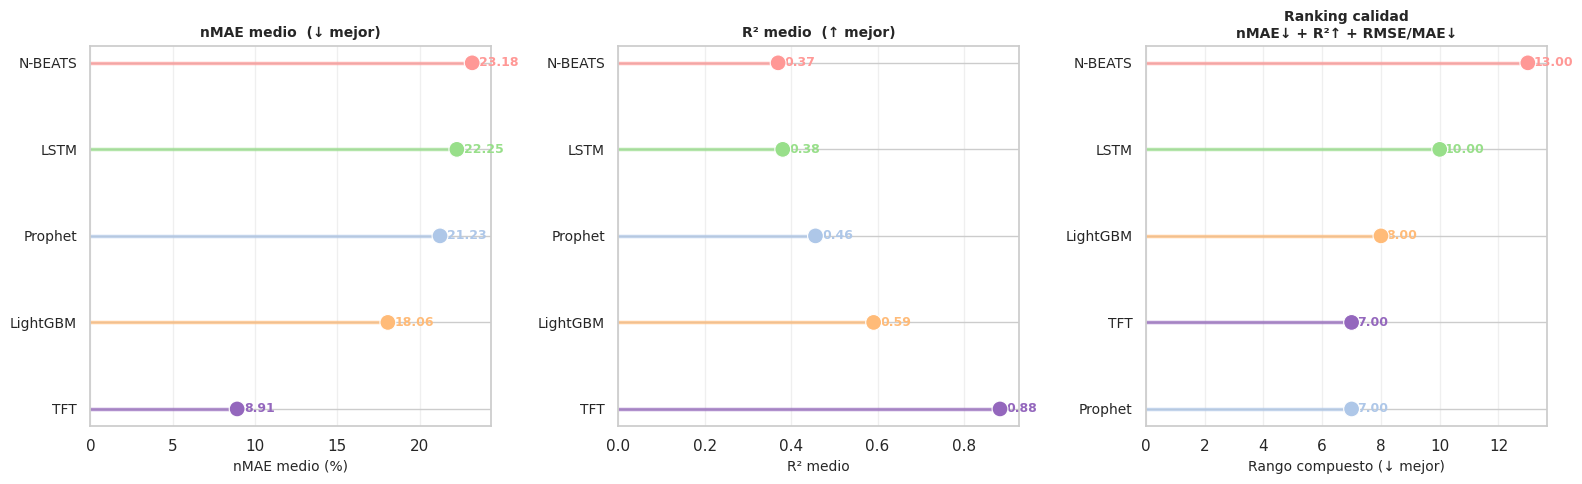

Guardado: exp1_ranking_lollipop.png


In [14]:
# ---------------------------------------------------------------------------
# CELDA 12 — Lollipop chart de ranking
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plots = [
    (axes[0], df_rank.sort_values('nMAE'),          'nMAE',         'nMAE medio (%)',          'nMAE medio  (↓ mejor)'),
    (axes[1], df_rank.sort_values('R2', ascending=False), 'R2',     'R² medio',                'R² medio  (↑ mejor)'),
    (axes[2], df_rank.sort_values('rank_calidad'),   'rank_calidad', 'Rango compuesto (↓ mejor)', 'Ranking calidad\nnMAE↓ + R²↑ + RMSE/MAE↓'),
]

for ax, df_s, col, xlabel, title in plots:
    mods = df_s.index.tolist()
    vals = df_s[col].values
    y    = np.arange(len(mods))
    clr  = [COLORS.get(m, 'gray') for m in mods]
    ax.hlines(y, 0, vals, colors=clr, lw=2.5, alpha=0.7)
    ax.scatter(vals, y, color=clr, s=130, zorder=4, edgecolors='white', lw=0.8)
    rng = vals.max() - vals.min() if vals.max() != vals.min() else 1
    for v, yi, m in zip(vals, y, mods):
        ax.text(v + rng * 0.03, yi, f'{v:.2f}', va='center', fontsize=9,
                color=COLORS.get(m, 'gray'), fontweight='bold')
    ax.set_yticks(y); ax.set_yticklabels(mods, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3); ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'exp1_ranking_lollipop.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: exp1_ranking_lollipop.png')


── Test de Friedman (H₀: todos los modelos son equivalentes en MAE) ──
  χ² = 14.5333  |  p = 0.005774  |  Rechazamos H₀ ✓
  (k=5 modelos, N=6 plantas, α=0.05)

── Rangos medios por modelo (rango 1 = menor MAE = mejor) ──
  TFT         : rango medio = 1.00
  LightGBM    : rango medio = 2.67
  Prophet     : rango medio = 3.50
  N-BEATS     : rango medio = 3.83
  LSTM        : rango medio = 4.00

── Wilcoxon pareado + Holm (10 pares) — α=0.05 ──
      m1       m2  stat_W   p_raw  p_holm resultado
 Prophet LightGBM     8.0 0.68750  1.0000      n.s.
 Prophet     LSTM     6.0 0.43750  1.0000      n.s.
 Prophet  N-BEATS     6.0 0.43750  1.0000      n.s.
 Prophet      TFT     0.0 0.03125  0.3125      n.s.
LightGBM     LSTM     4.0 0.21875  1.0000      n.s.
LightGBM  N-BEATS     2.0 0.09375  0.5625      n.s.
LightGBM      TFT     0.0 0.03125  0.3125      n.s.
    LSTM  N-BEATS     7.0 0.56250  1.0000      n.s.
    LSTM      TFT     0.0 0.03125  0.3125      n.s.
 N-BEATS      TFT     0.0 0.0312

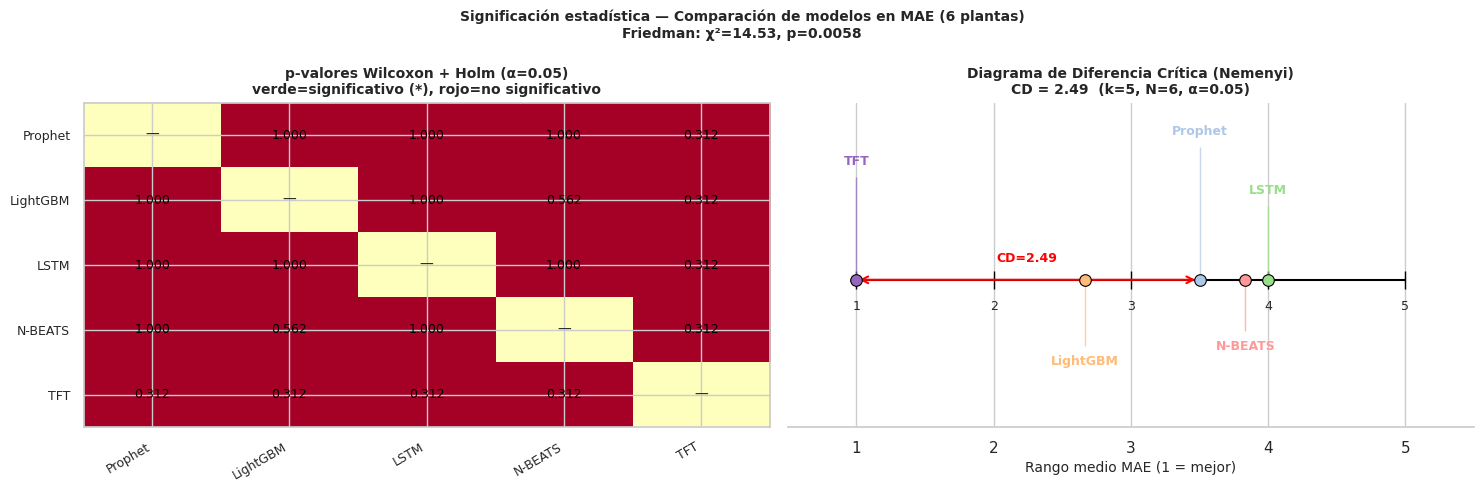

Guardado: exp1_statistical_tests.png
Exportado: statistical_tests_wilcoxon.csv


In [15]:
# ---------------------------------------------------------------------------
# CELDA 12b — Tests estadísticos: Friedman + Wilcoxon-Holm + CD diagram
# ---------------------------------------------------------------------------
# Referencia: Demšar (2006) "Statistical Comparisons of Classifiers over
# Multiple Data Sets" — JMLR 7:1-30.
#
# Configuración: k=5 modelos, N=6 plantas (obs. pareadas por planta).
# NOTA: con N=6 el poder estadístico es limitado. Los tests deben interpretarse
# como indicativos; evidencia confirmatoria se obtiene con más plantas.
#
# Procedimiento:
#   1. Test de Friedman — H₀: todos los modelos son equivalentes en MAE
#   2. Tests de Wilcoxon pareados (10 pares) + corrección Holm-Bonferroni
#   3. Diagrama de Diferencia Crítica (Nemenyi, α=0.05)

from itertools import combinations as _combs
from scipy import stats as _stats

ALPHA  = 0.05
_METRIC = 'MAE'

# ── 1. Matriz MAE (n_models × n_plantas) ─────────────────────────────────────
# Usamos pivot_table para manejar correctamente columnas Categorical
_pivot_mae = df_all.pivot_table(values=_METRIC, index='modelo', columns='planta', aggfunc='first')
_pivot_mae = _pivot_mae.reindex(index=modelos_disp, columns=PLANTAS)
_mae_mat   = _pivot_mae.values.astype(float)  # shape: (n_models, n_plantas)
if np.any(np.isnan(_mae_mat)):
    print('AVISO: combinaciones faltantes:')
    for _ii, _mm in enumerate(modelos_disp):
        for _jj, _pp in enumerate(PLANTAS):
            if np.isnan(_mae_mat[_ii, _jj]):
                print(f'  {_mm} × {_pp}')

n_m = len(modelos_disp)
n_p = len(PLANTAS)

# ── 2. Test de Friedman ───────────────────────────────────────────────────────
_chi2_fr, _p_fr = _stats.friedmanchisquare(*[_mae_mat[i] for i in range(n_m)])
print('── Test de Friedman (H₀: todos los modelos son equivalentes en MAE) ──')
print(f'  χ² = {_chi2_fr:.4f}  |  p = {_p_fr:.6f}  |  '
      f'{"Rechazamos H₀ ✓" if _p_fr < ALPHA else "No rechazamos H₀"}')
print(f'  (k={n_m} modelos, N={n_p} plantas, α={ALPHA})')
print()

# ── 3. Rangos medios por planta (para CD diagram) ─────────────────────────────
_ranks_mat = np.array([_stats.rankdata(_mae_mat[:, j]) for j in range(n_p)]).T
_avg_ranks = _ranks_mat.mean(axis=1)

print('── Rangos medios por modelo (rango 1 = menor MAE = mejor) ──')
for _m, _r in sorted(zip(modelos_disp, _avg_ranks), key=lambda x: x[1]):
    print(f'  {_m:<12}: rango medio = {_r:.2f}')
print()

# ── 4. Wilcoxon pareado para todos los pares de modelos ──────────────────────
_pairs_idx = list(_combs(range(n_m), 2))
_results_w = []
for _i, _j in _pairs_idx:
    _diff = _mae_mat[_i] - _mae_mat[_j]
    if np.all(_diff == 0):
        _stat, _pv = np.nan, 1.0
    else:
        _stat, _pv = _stats.wilcoxon(_diff, alternative='two-sided', zero_method='wilcox')
    _results_w.append({'m1': modelos_disp[_i], 'm2': modelos_disp[_j],
                       'stat_W': _stat, 'p_raw': _pv})

_df_w = pd.DataFrame(_results_w)

# ── 5. Corrección Holm-Bonferroni ─────────────────────────────────────────────
# Usamos np.argsort sobre array numpy para evitar el centinela -1 de pandas argsort
_n_tests    = len(_df_w)
_p_raw_vals = _df_w['p_raw'].fillna(1.0).to_numpy()
_sorted_pos = np.argsort(_p_raw_vals)   # numpy argsort: no -1 sentinel para NaN
_p_holm     = np.ones(_n_tests)
_p_run      = 0.0
for _rk, _pos in enumerate(_sorted_pos):
    _pc    = _p_raw_vals[_pos] * (_n_tests - _rk)
    _p_run = max(_p_run, _pc)
    _p_holm[_pos] = min(_p_run, 1.0)
_df_w['p_holm'] = _p_holm
_df_w['sig'] = _df_w['p_holm'] < ALPHA

print(f'── Wilcoxon pareado + Holm ({_n_tests} pares) — α={ALPHA} ──')
_df_show = _df_w[['m1', 'm2', 'stat_W', 'p_raw', 'p_holm', 'sig']].copy()
_df_show['resultado'] = _df_show['sig'].map({True: '✓ sig.', False: '  n.s.'})
print(_df_show[['m1', 'm2', 'stat_W', 'p_raw', 'p_holm', 'resultado']].to_string(index=False))
print(f'\n  Pares significativos (p_holm < {ALPHA}): '
      f'{_df_w["sig"].sum()} de {_n_tests}')

# ── 6. Figuras ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo: matriz de p-valores (color = significativo / n.s.)
_p_mat = np.ones((n_m, n_m))
for _, _row in _df_w.iterrows():
    _i_ = modelos_disp.index(_row['m1'])
    _j_ = modelos_disp.index(_row['m2'])
    _p_mat[_i_, _j_] = _p_mat[_j_, _i_] = _row['p_holm']

_sig_mat = (_p_mat < ALPHA).astype(float)
np.fill_diagonal(_sig_mat, 0.5)   # diagonal en gris

im = axes[0].imshow(_sig_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
for _i in range(n_m):
    for _j in range(n_m):
        if _i == _j:
            axes[0].text(_j, _i, '—', ha='center', va='center', fontsize=10)
        else:
            _txt = f'{_p_mat[_i, _j]:.3f}'
            _is_sig = _p_mat[_i, _j] < ALPHA
            axes[0].text(_j, _i, f'{_txt}{"*" if _is_sig else ""}',
                         ha='center', va='center', fontsize=9, color='black')

axes[0].set_xticks(range(n_m))
axes[0].set_yticks(range(n_m))
axes[0].set_xticklabels(modelos_disp, rotation=30, ha='right', fontsize=9)
axes[0].set_yticklabels(modelos_disp, fontsize=9)
axes[0].set_title(f'p-valores Wilcoxon + Holm (α={ALPHA})\n'
                  f'verde=significativo (*), rojo=no significativo',
                  fontsize=10, fontweight='bold')

# Panel derecho: diagrama de diferencia crítica (Nemenyi, Demšar 2006)
# CD = q_α × sqrt(k(k+1)/(6N))  — q_α para k=5, α=0.05: 2.728
_q_alpha_cd = 2.728
_CD = _q_alpha_cd * np.sqrt(n_m * (n_m + 1) / (6.0 * n_p))

_ord = np.argsort(_avg_ranks)
_mods_cd = [modelos_disp[i] for i in _ord]
_rnks_cd = [_avg_ranks[i]   for i in _ord]

ax_cd = axes[1]
ax_cd.set_xlim(0.5, n_m + 0.5)
ax_cd.set_ylim(-0.5, 1.7)
ax_cd.set_xlabel('Rango medio MAE (1 = mejor)', fontsize=10)
ax_cd.set_title(f'Diagrama de Diferencia Crítica (Nemenyi)\n'
                f'CD = {_CD:.2f}  (k={n_m}, N={n_p}, α={ALPHA})',
                fontsize=10, fontweight='bold')

# Eje de rangos
ax_cd.hlines(0.5, 1, n_m, colors='black', lw=1.5)
for _xt in range(1, n_m + 1):
    ax_cd.vlines(_xt, 0.44, 0.56, colors='black', lw=1)
    ax_cd.text(_xt, 0.36, str(_xt), ha='center', va='top', fontsize=9)

# Modelos: puntos con etiquetas alternadas arriba/abajo
_y_alt = [1.2, 0.05, 1.4, 0.15, 1.0]
for _k, (_mod, _r) in enumerate(zip(_mods_cd, _rnks_cd)):
    _ypos = _y_alt[_k % len(_y_alt)]
    ax_cd.scatter([_r], [0.5], s=70, color=COLORS.get(_mod, 'gray'),
                  zorder=5, edgecolors='black', lw=0.8)
    ax_cd.vlines(_r, 0.5, _ypos, colors=COLORS.get(_mod, 'gray'), lw=1, alpha=0.7)
    ax_cd.text(_r, _ypos + (0.06 if _ypos > 0.5 else -0.06), _mod,
               ha='center', va='bottom' if _ypos > 0.5 else 'top',
               fontsize=9, fontweight='bold', color=COLORS.get(_mod, 'gray'))

# Barra CD desde el modelo con mejor rango
_r_best = _rnks_cd[0]
ax_cd.annotate('', xy=(_r_best + _CD, 0.5), xytext=(_r_best, 0.5),
               arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
ax_cd.text((_r_best + _r_best + _CD) / 2, 0.62,
           f'CD={_CD:.2f}', ha='center', fontsize=9, color='red', fontweight='bold')
ax_cd.set_yticks([])
for _sp in ['left', 'right', 'top']:
    ax_cd.spines[_sp].set_visible(False)

plt.suptitle(
    f'Significación estadística — Comparación de modelos en MAE ({n_p} plantas)\n'
    f'Friedman: χ²={_chi2_fr:.2f}, p={_p_fr:.4f}',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'exp1_statistical_tests.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: exp1_statistical_tests.png')

# Exportar tabla de tests
_df_w[['m1', 'm2', 'stat_W', 'p_raw', 'p_holm', 'sig']].to_csv(
    OUT_DIR / 'statistical_tests_wilcoxon.csv', index=False
)
print(f'Exportado: statistical_tests_wilcoxon.csv')

# Limpieza
del _mae_mat, _ranks_mat, _avg_ranks, _pairs_idx, _results_w, _df_w
del _chi2_fr, _p_fr, _p_mat, _sig_mat, _ord, _mods_cd, _rnks_cd
del _q_alpha_cd, _CD, _r_best

---
## Gráfico 12c — Eficiencia: n_parámetros vs nMAE


n_parámetros y nMAE por modelo:
  Prophet      params=        10   nMAE=21.23%
  LightGBM     params=     5,000   nMAE=18.06%
  LSTM         params=    52,000   nMAE=22.25%
  N-BEATS      params= 1,500,000   nMAE=23.18%
  TFT          params= 2,500,000   nMAE=8.91%


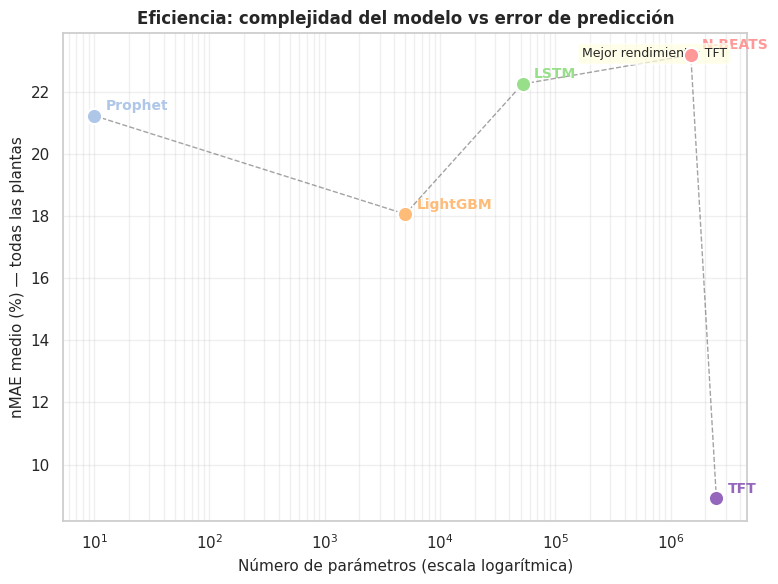

Guardado: exp1_nparams_vs_nmae.png


In [16]:
# ---------------------------------------------------------------------------
# CELDA 12c — Scatter: n_parámetros del modelo vs nMAE medio
# ---------------------------------------------------------------------------
# Muestra si la complejidad del modelo (n_params) está justificada por
# la mejora de rendimiento (nMAE). La línea de Pareto conecta los modelos
# eficientes (menor nMAE por parámetro).
# Valores de parámetros: estimaciones basadas en la arquitectura configurada.

# Parámetros aproximados de cada modelo (escala logarítmica)
_N_PARAMS = {
    'Prophet':  10,          # ~10 regressores + parámetros de tendencia/estacionalidad
    'LightGBM': 5_000,       # ~100 árboles × 50 hojas aprox.
    'LSTM':     52_000,       # hidden=128, input~40 features, 1 capa
    'N-BEATS':  1_500_000,    # 30 bloques × 512 unidades × capas
    'TFT':      2_500_000,    # attention + lstm_encoder/decoder + GRN
}

# nMAE medio por modelo (promedio sobre todas las plantas disponibles)
_df_nparams = df_all.groupby('modelo', observed=True)['nMAE'].mean().reset_index()
_df_nparams['n_params'] = _df_nparams['modelo'].map(_N_PARAMS)
_df_nparams = _df_nparams.dropna(subset=['n_params'])

print("n_parámetros y nMAE por modelo:")
for _, row in _df_nparams.iterrows():
    print(f"  {row['modelo']:<12} params={int(row['n_params']):>10,}   nMAE={row['nMAE']:.2f}%")

# Gráfico scatter
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in _df_nparams.iterrows():
    modelo = row['modelo']
    ax.scatter(row['n_params'], row['nMAE'],
               s=120, color=COLORS.get(modelo, 'grey'),
               zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate(
        modelo,
        xy=(row['n_params'], row['nMAE']),
        xytext=(8, 4),
        textcoords='offset points',
        fontsize=10, fontweight='bold',
        color=COLORS.get(modelo, 'grey')
    )

# Línea de tendencia (Pareto)
_sorted = _df_nparams.sort_values('n_params')
ax.plot(_sorted['n_params'], _sorted['nMAE'],
        'k--', lw=1, alpha=0.4, label='Tendencia')

ax.set_xscale('log')
ax.set_xlabel('Número de parámetros (escala logarítmica)', fontsize=11)
ax.set_ylabel('nMAE medio (%) — todas las plantas', fontsize=11)
ax.set_title('Eficiencia: complejidad del modelo vs error de predicción',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.tick_params(axis='x', which='minor', length=4)

# Anotación interpretativa
_best_model = _df_nparams.loc[_df_nparams['nMAE'].idxmin(), 'modelo']
ax.text(0.97, 0.97,
        f'Mejor rendimiento: {_best_model}',
        transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.savefig(FIG_DIR / 'exp1_nparams_vs_nmae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: exp1_nparams_vs_nmae.png')


In [17]:
# ---------------------------------------------------------------------------
# CELDA 13 — Exportar tablas consolidadas
# ---------------------------------------------------------------------------
export_cols = ['modelo', 'planta', 'zona_climatica', 'capacidad_mw',
               'n_samples', 'MAE', 'RMSE', 'R2', 'nMAE', 'RMSE_MAE']
if 'training_time_s' in df_all.columns:
    export_cols.append('training_time_s')
export_cols = [c for c in export_cols if c in df_all.columns]

out_detail = OUT_DIR / 'comparison_exp1_all.csv'
df_all[export_cols].sort_values(['modelo', 'planta']).to_csv(out_detail, index=False)
print(f'Tabla detallada: {out_detail}')

out_rank = OUT_DIR / 'comparison_exp1_ranking.csv'
df_rank.to_csv(out_rank)
print(f'Tabla ranking:   {out_rank}')

print()
print('=== Figuras generadas ===')
for f in sorted(FIG_DIR.glob('exp1_*.png')):
    print(f'  {f.name}')
print()
print('Notebook 06_comparison completado.')


Tabla detallada: results/ex1_compare/comparison_exp1_all.csv
Tabla ranking:   results/ex1_compare/comparison_exp1_ranking.csv

=== Figuras generadas ===
  exp1_dashboard_plantas.png
  exp1_efficiency_frontier.png
  exp1_error_por_condicion_meteo.png
  exp1_heatmaps_quality.png
  exp1_mae_r2_bars.png
  exp1_nparams_vs_nmae.png
  exp1_radar_models.png
  exp1_ranking_lollipop.png
  exp1_rmse_mae_analysis.png
  exp1_statistical_tests.png
  exp1_training_time.png
  exp1_zona_climatica.png

Notebook 06_comparison completado.
